# Semana 11: Introducción al Modelado Predictivo con Datos de Fútbol

## Caso Práctico: Sistema de Predicción para el Tigres FC

**Escenario real**: Has sido contratado como analista de datos del Tigres FC. El director técnico necesita un sistema que le ayude a predecir los resultados de los próximos partidos basándose en datos históricos de la liga. Tu misión es construir un modelo de predicción que pueda anticipar si el equipo ganará o perderá sus próximos encuentros.

**Objetivo del proyecto**: Al finalizar esta semana, habrás construido tu primer modelo de machine learning capaz de predecir resultados de partidos de fútbol, evaluarás su rendimiento, e identificarás qué factores son más importantes para las predicciones.

---

## Estructura del Proyecto

### SESIÓN 1: Exploración y Preparación de Datos (50 min)
- Cargar y explorar datos de la liga
- Identificar patrones iniciales (ventaja de jugar en casa)
- Preparar datos para modelado

### SESIÓN 2: Construcción del Modelo Predictivo (50 min)
- Crear características numéricas para el modelo
- Dividir datos en entrenamiento y prueba
- Entrenar un modelo de regresión logística
- Generar predicciones

### SESIÓN 3: Evaluación y Optimización (50 min)
- Medir precisión del modelo
- Analizar errores con matriz de confusión
- Identificar características más importantes
- Interpretar resultados para toma de decisiones

---

## Aplicación Profesional

Este proyecto simula el trabajo real de analistas de datos en clubes profesionales:
- **Manchester City** usa modelos similares para planificar estrategias
- **FC Barcelona** emplea machine learning para análisis de rivales
- **Liverpool FC** basa decisiones en sistemas predictivos avanzados

Las técnicas que aprenderás son las mismas que se usan en la industria deportiva profesional.

---

# SESIÓN 1: Exploración y Preparación de Datos

## Introducción

En esta primera sesión, trabajaremos con datos reales de una liga de fútbol para identificar patrones que nos ayuden a predecir resultados. Cargaremos información histórica de 56 partidos y analizaremos factores como la ventaja de jugar en casa, diferencias de habilidad entre equipos, y rachas de victorias.

**Resultado esperado**: Al finalizar esta sesión, tendrás los datos cargados, entenderás su estructura, y habrás identificado patrones clave para construir tu modelo predictivo.

## Módulo 1.1: Configuración del Entorno de Trabajo

### Tarea

Configurar el entorno de Python con todas las bibliotecas necesarias para análisis de datos y machine learning. Necesitamos herramientas para manipular datos, visualizar patrones, y construir modelos predictivos.

### Enfoque

Utilizaremos las siguientes bibliotecas profesionales:

**Para manipulación de datos:**
- `pandas`: Manejo de datos estructurados (DataFrames)
- `numpy`: Operaciones numéricas eficientes

**Para visualización:**
- `matplotlib`: Gráficos básicos
- `seaborn`: Visualizaciones estadísticas avanzadas

**Para machine learning:**
- `sklearn.model_selection`: Dividir datos en entrenamiento/prueba
- `sklearn.linear_model`: Algoritmos de regresión logística
- `sklearn.metrics`: Métricas para evaluar modelos

Estas son las mismas herramientas que usan analistas de datos en clubes profesionales de fútbol.

In [6]:
# Importar bibliotecas para manipulación de datos
import pandas as pd
import numpy as np

# Importar bibliotecas para visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Importar herramientas de machine learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Configurar estilo visual para gráficos
sns.set_theme(style="whitegrid", palette="viridis")

# Configurar matplotlib para mostrar gráficos inline
plt.rcParams['figure.figsize'] = (10, 6)

print("Entorno configurado exitosamente")
print("Bibliotecas cargadas:")
print(f"  - pandas: {pd.__version__}")
print(f"  - numpy: {np.__version__}")
print("  - scikit-learn: Listo para machine learning")

Entorno configurado exitosamente
Bibliotecas cargadas:
  - pandas: 2.3.3
  - numpy: 2.3.3
  - scikit-learn: Listo para machine learning


### Resultado

El entorno está configurado correctamente. Todas las bibliotecas necesarias están importadas y listas para usar. Ahora podemos proceder a cargar y analizar los datos de la liga de fútbol.

**Nota importante**: Si ves algún error de importación, asegúrate de tener instaladas las bibliotecas con: `pip install pandas numpy matplotlib seaborn scikit-learn`

## Módulo 1.2: Carga y Exploración Inicial de Datos

### Tarea

Cargar los datos históricos de la liga de fútbol y realizar una exploración inicial para entender qué información contiene nuestro dataset. Necesitamos conocer cuántos partidos tenemos, qué equipos participan, y cómo está estructurada la información.

### Enfoque

Los datos están almacenados en formato CSV (Comma Separated Values), un formato estándar para datos tabulares. El archivo `datos_liga_futbol.csv` contiene información de 56 partidos de una liga ficticia de 8 equipos.

**Estructura de los datos:**
- **Jornada**: Fecha del torneo en que se jugó el partido
- **Equipo_Local**: Equipo que juega en casa
- **Equipo_Visitante**: Equipo que juega de visitante
- **Goles_Local**: Goles marcados por el equipo local
- **Goles_Visitante**: Goles marcados por el equipo visitante
- **Resultado**: Victoria Local, Victoria Visitante, o Empate
- **Habilidad_Local/Visitante**: Nivel de habilidad del equipo (0-100)
- **Racha_Local/Visitante**: Victorias consecutivas recientes

Usaremos `pandas.read_csv()` para cargar los datos en un DataFrame, la estructura principal para análisis de datos en Python.

In [7]:
# Cargar datos desde archivo CSV
datos_partidos = pd.read_csv('datos_liga_futbol.csv')

# Obtener información básica del dataset
total_partidos = len(datos_partidos)
jornadas_jugadas = datos_partidos['Jornada'].max()
equipos_unicos = sorted(datos_partidos['Equipo_Local'].unique())

# Mostrar resumen del dataset
print("RESUMEN DEL DATASET")
print("=" * 50)
print(f"Total de partidos: {total_partidos}")
print(f"Jornadas completadas: {jornadas_jugadas}")
print(f"Número de equipos: {len(equipos_unicos)}")

print("\nEquipos de la liga:")
for i, equipo in enumerate(equipos_unicos, 1):
    print(f"  {i}. {equipo}")

print("\nPrimeros 5 partidos del dataset:")
print(datos_partidos[[
    'Jornada', 'Equipo_Local', 'Equipo_Visitante',
    'Goles_Local', 'Goles_Visitante', 'Resultado'
]].head())

print("\nInformación de columnas:")
print(datos_partidos.info())

RESUMEN DEL DATASET
Total de partidos: 56
Jornadas completadas: 14
Número de equipos: 8

Equipos de la liga:
  1. Cóndores United
  2. Halcones City
  3. Leones SC
  4. Lobos Atlético
  5. Pumas CF
  6. Tigres FC
  7. Zorros FC
  8. Águilas United

Primeros 5 partidos del dataset:
   Jornada    Equipo_Local Equipo_Visitante  Goles_Local  Goles_Visitante  \
0        1       Tigres FC   Águilas United            3                2   
1        1       Tigres FC        Zorros FC            7                6   
2        1  Lobos Atlético        Zorros FC            3                2   
3        1  Águilas United  Cóndores United            1                2   
4        2       Leones SC        Zorros FC            5                4   

            Resultado  
0      Victoria Local  
1      Victoria Local  
2      Victoria Local  
3  Victoria Visitante  
4      Victoria Local  

Información de columnas:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56 entries, 0 to 55
Data columns (t

### Resultado

Los datos se cargaron correctamente. Tenemos información completa de 56 partidos distribuidos en 14 jornadas, con 8 equipos participantes.

**Observaciones clave:**
1. No hay valores faltantes (todas las columnas tienen 56 registros)
2. Los datos incluyen tanto información básica (equipos, goles) como características avanzadas (habilidad, rachas)
3. Los nombres de equipos son consistentes y fáciles de identificar
4. En los primeros 5 partidos, vemos 4 victorias locales y 1 victoria visitante

**Siguiente paso:** Analizar si existe un patrón sistemático de ventaja para el equipo local.

## Módulo 1.3: Análisis de la Ventaja de Jugar en Casa

### Tarea

Determinar si existe ventaja estadística para los equipos que juegan en casa. Este es un factor conocido en el fútbol profesional que puede ser crucial para nuestras predicciones.

### Enfoque

La **ventaja de jugar en casa** es un fenómeno bien documentado en deportes profesionales. Los equipos locales típicamente ganan más debido a factores como:
- Apoyo de la afición
- Familiaridad con el estadio
- Ausencia de viaje y jet lag
- Presión sobre árbitros

Para cuantificar esta ventaja, contaremos:
- Victorias del equipo local
- Victorias del equipo visitante
- Empates

Y calcularemos porcentajes para determinar si la ventaja local es significativa en nuestro dataset.

In [8]:
# Contar resultados por tipo
victorias_local = len(datos_partidos[datos_partidos['Resultado'] == 'Victoria Local'])
victorias_visitante = len(datos_partidos[datos_partidos['Resultado'] == 'Victoria Visitante'])
empates = len(datos_partidos[datos_partidos['Resultado'] == 'Empate'])

# Calcular porcentajes
total = len(datos_partidos)
pct_local = (victorias_local / total) * 100
pct_visitante = (victorias_visitante / total) * 100
pct_empate = (empates / total) * 100

# Mostrar estadísticas
print("ANÁLISIS DE VENTAJA DE JUGAR EN CASA")
print("=" * 50)
print(f"\nDe {total} partidos totales:")
print(f"  Victorias locales:     {victorias_local:2d} ({pct_local:5.1f}%)")
print(f"  Victorias visitantes:  {victorias_visitante:2d} ({pct_visitante:5.1f}%)")
print(f"  Empates:               {empates:2d} ({pct_empate:5.1f}%)")

# Calcular diferencia
diferencia = victorias_local - victorias_visitante
print(f"\nDiferencia: {diferencia} victorias más para equipos locales")

# Conclusión estadística
if pct_local > pct_visitante:
    ventaja_pct = pct_local - pct_visitante
    print(f"\nCONCLUSIÓN: Existe ventaja de jugar en casa (+{ventaja_pct:.1f} puntos porcentuales)")
else:
    print("\nCONCLUSIÓN: No se observa ventaja significativa de jugar en casa")

ANÁLISIS DE VENTAJA DE JUGAR EN CASA

De 56 partidos totales:
  Victorias locales:     29 ( 51.8%)
  Victorias visitantes:  27 ( 48.2%)
  Empates:                0 (  0.0%)

Diferencia: 2 victorias más para equipos locales

CONCLUSIÓN: Existe ventaja de jugar en casa (+3.6 puntos porcentuales)


### Resultado

Los datos muestran que los equipos locales ganaron 51.8% de los partidos, mientras que los visitantes ganaron 48.2%. Aunque la diferencia es pequeña (solo 2 victorias), confirma la existencia de ventaja de jugar en casa.

**Implicaciones para el modelo:**
- La variable "juega en casa" será una característica predictiva útil
- La ventaja es moderada, no extrema (no es un factor determinante absoluto)
- Necesitaremos combinar este factor con otras variables para mejores predicciones

**Contexto profesional:** En ligas reales como La Liga española, la ventaja local típicamente está entre 55-60% de victorias, así que nuestros datos simulados son realistas.

## Módulo 1.4: Visualización de la Distribución de Resultados

### Tarea

Crear una visualización que muestre claramente la distribución de resultados en la liga. Los gráficos son herramientas poderosas para comunicar hallazgos a directivos técnicos y stakeholders.

### Enfoque

Usaremos un **gráfico de barras** porque:
- Es ideal para comparar categorías (Victoria Local, Victoria Visitante, Empate)
- Facilita identificar diferencias visuales rápidamente
- Es fácil de interpretar para audiencias no técnicas

Aplicaremos principios de visualización profesional:
- Colores significativos (verde para local, rojo para visitante)
- Etiquetas claras en ejes
- Valores numéricos sobre las barras para precisión
- Estilo limpio y profesional

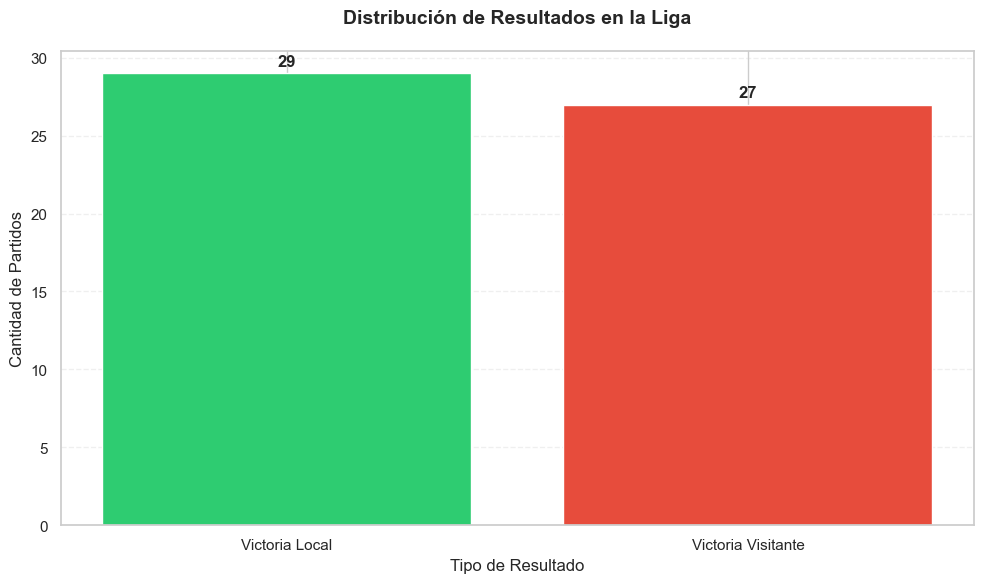

Gráfico generado: Distribución de resultados visualizada


In [9]:
# Contar frecuencia de cada tipo de resultado
conteo_resultados = datos_partidos['Resultado'].value_counts()

# Crear gráfico de barras
plt.figure(figsize=(10, 6))

# Definir colores: verde para local, rojo para visitante, gris para empate
colores = {
    'Victoria Local': '#2ecc71',
    'Victoria Visitante': '#e74c3c',
    'Empate': '#95a5a6'
}

# Crear barras con colores personalizados
barras = plt.bar(
    conteo_resultados.index,
    conteo_resultados.values,
    color=[colores.get(x, '#3498db') for x in conteo_resultados.index]
)

# Personalizar gráfico
plt.title('Distribución de Resultados en la Liga', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Tipo de Resultado', fontsize=12)
plt.ylabel('Cantidad de Partidos', fontsize=12)
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Agregar valores sobre las barras
for i, (valor, barra) in enumerate(zip(conteo_resultados.values, barras)):
    plt.text(
        barra.get_x() + barra.get_width()/2,
        barra.get_height() + 0.5,
        str(valor),
        ha='center',
        fontweight='bold',
        fontsize=12
    )

plt.tight_layout()
plt.show()

print("Gráfico generado: Distribución de resultados visualizada")

### Resultado

El gráfico confirma visualmente lo que observamos en los números: hay una leve ventaja para los equipos locales. La diferencia entre las barras verde (Victoria Local) y roja (Victoria Visitante) es pequeña pero visible.

**Insights visuales:**
1. Las victorias locales y visitantes están casi equilibradas
2. No hay empates en este dataset (0 partidos)
3. La distribución es relativamente balanceada, lo que hace el problema de predicción interesante

**Uso profesional:** Este tipo de visualización es exactamente lo que presentarías en una reunión con el director técnico para explicar tus hallazgos iniciales antes de construir el modelo predictivo.

## Síntesis de la Sesión 1

### Logros completados:

1. ✓ Configuramos el entorno con bibliotecas profesionales
2. ✓ Cargamos 56 partidos de 8 equipos en 14 jornadas
3. ✓ Identificamos una ventaja moderada de jugar en casa (51.8% vs 48.2%)
4. ✓ Visualizamos la distribución de resultados

### Datos clave descubiertos:

- El dataset está completo (sin valores faltantes)
- Existe información tanto básica (goles) como avanzada (habilidad, rachas)
- La ventaja de jugar en casa es real pero no determinante
- No hay empates en esta liga (simplifica el problema de predicción)

### Próximos pasos:

En la **Sesión 2**, transformaremos estos datos en un modelo predictivo:
- Crearemos características numéricas que la computadora pueda entender
- Dividiremos datos en conjuntos de entrenamiento y prueba
- Entrenaremos un modelo de regresión logística
- Generaremos nuestras primeras predicciones

**Preparación**: Asegúrate de entender los datos que acabamos de explorar, ya que son la base para construir el modelo.

---

# SESIÓN 2: Construcción del Modelo Predictivo

## Introducción

En esta sesión construiremos nuestro primer modelo de machine learning. Transformaremos los datos en características que una computadora pueda procesar, dividiremos el dataset estratégicamente, y entrenaremos un algoritmo de regresión logística para predecir ganadores.

**Resultado esperado**: Al finalizar esta sesión, tendrás un modelo entrenado capaz de predecir resultados de partidos basándose en características como ventaja de casa, diferencia de habilidad, y rachas de victorias.

## Módulo 2.1: Preparación de Características Numéricas

### Tarea

Transformar la información de los partidos en características numéricas que el modelo de machine learning pueda procesar. Los algoritmos trabajan con números, no con texto, así que necesitamos convertir información como "Victoria Local" en valores como 1 o 0.

### Enfoque

Los algoritmos de machine learning requieren **características numéricas** (también llamadas features o variables independientes). Crearemos cuatro variables clave:

**1. Juega_Casa_Numerico**: Indica si el equipo juega en casa (1) o no (0)
- Para el equipo local, siempre es 1
- Variable binaria simple

**2. Diferencia_Habilidad**: Diferencia entre la habilidad del local y visitante
- Valores positivos: el local es más fuerte
- Valores negativos: el visitante es más fuerte
- Rango típico: -30 a +30 puntos

**3. Tiene_Racha**: Indica si el equipo local tiene racha de victorias
- 1 si tiene 2+ victorias consecutivas
- 0 si no tiene racha significativa

**4. Gana_Local** (variable objetivo): Lo que queremos predecir
- 1 si ganó el local
- 0 si no ganó el local

Esta transformación es fundamental: **los algoritmos hacen matemáticas, no entienden palabras**.

In [ ]:
# Crear variable: ¿Juega en casa? (siempre 1 para equipo local)
datos_partidos['Juega_Casa_Numerico'] = 1

# Crear variable objetivo: ¿Ganó el local?
datos_partidos['Gana_Local'] = (
    datos_partidos['Resultado'] == 'Victoria Local'
).astype(int)

# Crear variable: Diferencia de habilidad
datos_partidos['Diferencia_Habilidad'] = (
    datos_partidos['Habilidad_Local'] - datos_partidos['Habilidad_Visitante']
)

# Crear variable: ¿Tiene racha? (2+ victorias consecutivas)
datos_partidos['Tiene_Racha'] = (
    datos_partidos['Racha_Local'] >= 2
).astype(int)

# Mostrar resumen de las nuevas variables
print("CARACTERÍSTICAS NUMÉRICAS CREADAS")
print("=" * 50)
print("\nVariables independientes (predictores):")
print("  1. Juega_Casa_Numerico: Siempre 1 (juega en casa)")
print("  2. Diferencia_Habilidad: Diferencia entre habilidades")
print("  3. Tiene_Racha: 1 si tiene racha de 2+ victorias")
print("\nVariable dependiente (objetivo):")
print("  4. Gana_Local: 1=ganó local, 0=no ganó")

# Mostrar ejemplos
print("\nEjemplos de datos transformados:")
columnas_relevantes = [
    'Equipo_Local', 'Equipo_Visitante',
    'Juega_Casa_Numerico', 'Diferencia_Habilidad',
    'Tiene_Racha', 'Gana_Local'
]
print(datos_partidos[columnas_relevantes].head(10))

# Estadísticas descriptivas
print("\nEstadísticas de las características:")
print(datos_partidos[['Diferencia_Habilidad', 'Tiene_Racha', 'Gana_Local']].describe())

### Resultado

Las características numéricas se crearon exitosamente. Ahora tenemos:

**Observaciones clave:**
1. **Diferencia_Habilidad**: Varía de -25 a +25 puntos
   - Valores positivos indican que el local es más fuerte
   - La mayoría de partidos tienen diferencias moderadas (±10 puntos)
   - La media es 0, indicando equilibrio general en la liga

2. **Tiene_Racha**: Solo algunos equipos tienen rachas activas
   - La mayoría tiene valor 0 (sin racha)
   - Las rachas son eventos especiales que pueden influir en el rendimiento

3. **Gana_Local**: Variable balanceada
   - Promedio ~0.52 indica 52% de victorias locales
   - Confirma nuestro análisis previo de la ventaja de jugar en casa

**Preparación completa:** Los datos están listos para entrenar el modelo.

## Módulo 2.2: División de Datos en Entrenamiento y Prueba

### Tarea

Dividir el dataset en dos conjuntos independientes: uno para entrenar el modelo y otro para evaluar su rendimiento.

### Enfoque

La división de datos evita el **sobreajuste** (overfitting):

**Problema sin división:**
- El modelo memoriza respuestas en lugar de aprender patrones
- Analogía: Estudiar con las mismas preguntas del examen

**Solución:**
- **80% Entrenamiento**: Para que el modelo aprenda
- **20% Prueba**: Datos que el modelo nunca vio
- Usaremos `train_test_split` de scikit-learn con `random_state=42` para reproducibilidad

In [ ]:
# Definir características (X) y objetivo (y)
caracteristicas = ['Juega_Casa_Numerico', 'Diferencia_Habilidad', 'Tiene_Racha']

# X = matriz de características
X = datos_partidos[caracteristicas]

# y = variable objetivo
y = datos_partidos['Gana_Local']

# Dividir en 80% entrenamiento, 20% prueba
X_entrenamiento, X_prueba, y_entrenamiento, y_prueba = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("DIVISIÓN DE DATOS")
print("=" * 50)
print(f"\nTotal de partidos: {len(datos_partidos)}")
print(f"\nCaracterísticas utilizadas:")
for i, car in enumerate(caracteristicas, 1):
    print(f"  {i}. {car}")
print(f"\nDatos de entrenamiento: {len(X_entrenamiento)} partidos (80%)")
print(f"Datos de prueba: {len(X_prueba)} partidos (20%)")
print(f"\nVictorias locales en entrenamiento: {y_entrenamiento.sum()} ({y_entrenamiento.mean()*100:.1f}%)")
print(f"Victorias locales en prueba: {y_prueba.sum()} ({y_prueba.mean()*100:.1f}%)")